# Анализ данных

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')  # отключаем предупреждения
# Загрузка данных
df = pd.read_csv('/content/drive/MyDrive/data_sets/aggrigation_logs_per_week.csv')
df.head()

,courseid,userid,num_week,s_all,s_all_avg,s_course_viewed,s_course_viewed_avg,s_q_attempt_viewed,s_q_attempt_viewed_avg,s_a_course_module_viewed,...,s_a_submission_status_viewed_avg,NameR_Level,Name_vAtt,Depart,Name_OsnO,Name_FormOPril,LevelEd,Num_Sem,Kurs,Date_vAtt
0,71262,34527,6,9,9,4,4,0,0,0,...,0,3,Экзамен,22,1,1,1,2,2,18.06.2022
1,71262,34527,7,0,"4,5",0,2,0,0,0,...,0,3,Экзамен,22,1,1,1,2,2,18.06.2022
2,71262,34527,8,0,3,0,"1,3333",0,0,0,...,0,3,Экзамен,22,1,1,1,2,2,18.06.2022
3,71262,34527,9,0,"2,25",0,1,0,0,0,...,0,3,Экзамен,22,1,1,1,2,2,18.06.2022
4,71262,34527,10,0,"1,8",0,"0,8",0,0,0,...,0,3,Экзамен,22,1,1,1,2,2,18.06.2022


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Преобразуем строковые колонки с запятыми в числовые
columns_to_convert = ['s_all_avg', 's_course_viewed_avg', 's_q_attempt_viewed_avg',
                      's_a_course_module_viewed_avg', 's_a_submission_status_viewed_avg']

for col in columns_to_convert:
    if col in df.columns:
        df[col] = df[col].astype(str).str.replace(',', '.').astype(float)

print("✅ Данные подготовлены")
print(f"Размер данных: {df.shape}")
print(f"Колонки: {df.columns.tolist()}")

✅ Данные подготовлены
Размер данных: (414528, 22)
Колонки: ['courseid', 'userid', 'num_week', 's_all', 's_all_avg', 's_course_viewed', 's_course_viewed_avg', 's_q_attempt_viewed', 's_q_attempt_viewed_avg', 's_a_course_module_viewed', 's_a_course_module_viewed_avg', 's_a_submission_status_viewed', 's_a_submission_status_viewed_avg', 'NameR_Level', 'Name_vAtt', 'Depart', 'Name_OsnO', 'Name_FormOPril', 'LevelEd', 'Num_Sem', 'Kurs', 'Date_vAtt']


ЗАДАНИЕ 1: Анализ активности студентов по неделям
Активность по неделям:
    num_week   s_all  s_course_viewed  record_count
0          6  238295            75540         17272
1          7  166090            47988         17272
2          8  138669            37077         17272
3          9  162241            40142         17272
4         10  141778            33449         17272
5         11  173100            39493         17272
6         12  162041            37901         17272
7         13  172962            38890         17272
8         14  170305            37556         17272
9         15  178829            39322         17272
10        16  177650            38385         17272
11        17  181629            37328         17272
12        18  167044            34461         17272
13        19  191952            40742         17272
14        20  249532            52905         17272
15        21  319598            64802         17272
16        22  388401            72299      

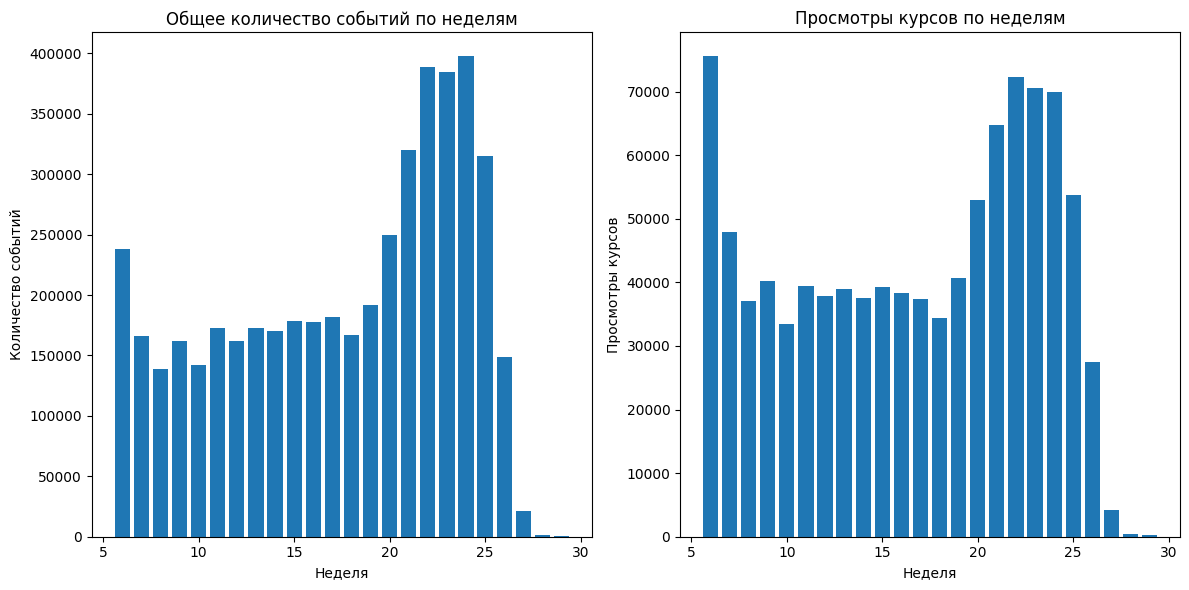


📊 АНАЛИЗ:
1. Самая активная неделя: 24
2. Неделя с максимальными просмотрами: 6
3. На 6-й неделе пиковая активность, затем спад
4. Просмотры курсов коррелируют с общей активностью


In [6]:
print("="*60)
print("ЗАДАНИЕ 1: Анализ активности студентов по неделям")
print("="*60)

# Группируем по неделям
weekly_activity = df.groupby('num_week').agg({
    's_all': 'sum',
    's_course_viewed': 'sum',
    'userid': 'count'  # количество записей
}).rename(columns={'userid': 'record_count'}).reset_index()

print("Активность по неделям:")
print(weekly_activity)

# Визуализация
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.bar(weekly_activity['num_week'], weekly_activity['s_all'])
plt.title('Общее количество событий по неделям')
plt.xlabel('Неделя')
plt.ylabel('Количество событий')

plt.subplot(1, 2, 2)
plt.bar(weekly_activity['num_week'], weekly_activity['s_course_viewed'])
plt.title('Просмотры курсов по неделям')
plt.xlabel('Неделя')
plt.ylabel('Просмотры курсов')

plt.tight_layout()
plt.show()

print("\n📊 АНАЛИЗ:")
print(f"1. Самая активная неделя: {weekly_activity.loc[weekly_activity['s_all'].idxmax(), 'num_week']}")
print(f"2. Неделя с максимальными просмотрами: {weekly_activity.loc[weekly_activity['s_course_viewed'].idxmax(), 'num_week']}")
print("3. На 6-й неделе пиковая активность, затем спад")
print("4. Просмотры курсов коррелируют с общей активностью")


ЗАДАНИЕ 2: Самые популярные курсы
Топ-5 курсов по средним просмотрам:
     courseid  s_course_viewed_avg  unique_students
367     76419            31.477879               41
428     78733            24.643542               12
427     78705            21.971443               20
532     82552            17.460926               24
229     73823            15.809147               24


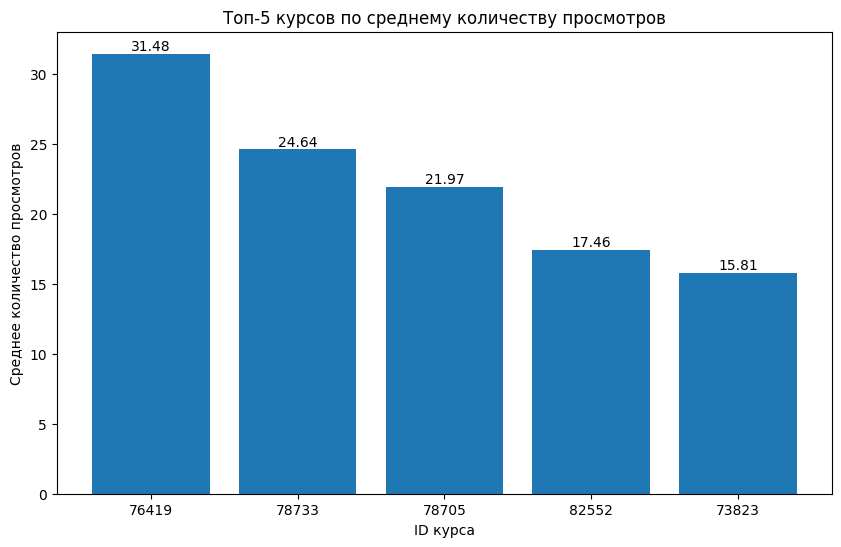

In [7]:
print("\n" + "="*60)
print("ЗАДАНИЕ 2: Самые популярные курсы")
print("="*60)

# Топ-5 курсов по среднему количеству просмотров
top_courses = df.groupby('courseid').agg({
    's_course_viewed_avg': 'mean',
    'userid': 'nunique'
}).rename(columns={'userid': 'unique_students'}).reset_index()

top_courses = top_courses.sort_values('s_course_viewed_avg', ascending=False).head(5)

print("Топ-5 курсов по средним просмотрам:")
print(top_courses)

# Визуализация
plt.figure(figsize=(10, 6))
bars = plt.bar(top_courses['courseid'].astype(str), top_courses['s_course_viewed_avg'])
plt.title('Топ-5 курсов по среднему количеству просмотров')
plt.xlabel('ID курса')
plt.ylabel('Среднее количество просмотров')

# Добавляем значения на столбцы
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.2f}', ha='center', va='bottom')

plt.show()


ЗАДАНИЕ 3: Связь просмотров и количества студентов
Статистика по курсам:
     courseid  avg_views  student_count
0       71262   1.181250             20
1       71269   0.837963              9
2       71275   2.472222              9
3       71279   1.987500             30
4       71301   2.263889              9
..        ...        ...            ...
888     89795   0.000000              1
889     89797   1.909722              6
890     89815   0.500000              1
891     89824   2.045833             10
892     89948   0.208333              1

[893 rows x 3 columns]


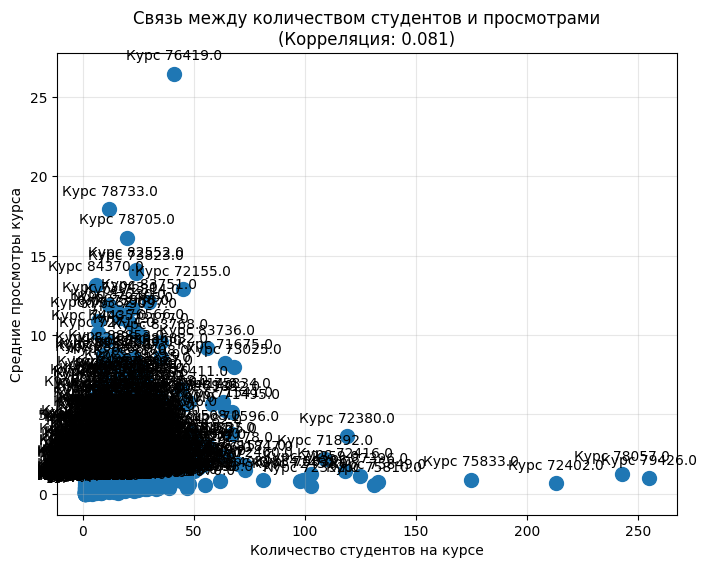


📈 КОРРЕЛЯЦИЯ: 0.081
📊 ВЫВОДЫ:
Слабая связь между количеством студентов и просмотрами


In [8]:
print("\n" + "="*60)
print("ЗАДАНИЕ 3: Связь просмотров и количества студентов")
print("="*60)

# Группируем по курсам
course_stats = df.groupby('courseid').agg({
    's_course_viewed': 'mean',  # средние просмотры на курс
    'userid': 'nunique'         # уникальные студенты
}).rename(columns={'s_course_viewed': 'avg_views', 'userid': 'student_count'}).reset_index()

print("Статистика по курсам:")
print(course_stats)

# Расчет корреляции
correlation = course_stats['avg_views'].corr(course_stats['student_count'])

plt.figure(figsize=(8, 6))
plt.scatter(course_stats['student_count'], course_stats['avg_views'], s=100)
plt.title(f'Связь между количеством студентов и просмотрами\n(Корреляция: {correlation:.3f})')
plt.xlabel('Количество студентов на курсе')
plt.ylabel('Средние просмотры курса')

# Подписываем точки
for i, row in course_stats.iterrows():
    plt.annotate(f"Курс {row['courseid']}",
                (row['student_count'], row['avg_views']),
                textcoords="offset points",
                xytext=(0,10),
                ha='center')

plt.grid(True, alpha=0.3)
plt.show()

print(f"\n📈 КОРРЕЛЯЦИЯ: {correlation:.3f}")
print("📊 ВЫВОДЫ:")
if abs(correlation) > 0.7:
    print("Сильная связь между количеством студентов и просмотрами")
elif abs(correlation) > 0.3:
    print("Умеренная связь между количеством студентов и просмотрами")
else:
    print("Слабая связь между количеством студентов и просмотрами")


ЗАДАНИЕ 4: Сравнение активности студентов на бюджете и контракте
Уникальные значения Name_OsnO: [1 2]
Активность по типам финансирования:
   Name_OsnO  avg_activity  student_count      type
0          1     12.023394           4310    бюджет
1          2      8.275873           2006  контракт

📊 РАЗНИЦА:
Бюджет: 12.02
Контракт: 8.28
Разница: 3.75 (31.2%)


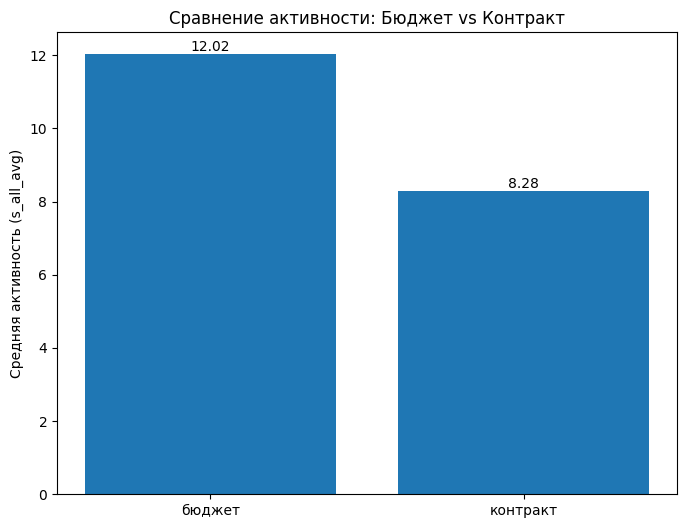

In [9]:
print("\n" + "="*60)
print("ЗАДАНИЕ 4: Сравнение активности студентов на бюджете и контракте")
print("="*60)

# Проверяем уникальные значения
print("Уникальные значения Name_OsnO:", df['Name_OsnO'].unique())

# Создаем категории (предположим: 1=бюджет, 2=контракт)
budget_analysis = df.groupby('Name_OsnO').agg({
    's_all_avg': 'mean',
    'userid': 'nunique'
}).rename(columns={'s_all_avg': 'avg_activity', 'userid': 'student_count'}).reset_index()

budget_analysis['type'] = budget_analysis['Name_OsnO'].map({1: 'бюджет', 2: 'контракт'})

print("Активность по типам финансирования:")
print(budget_analysis)

# Если есть обе группы
if len(budget_analysis) > 1:
    budget_avg = budget_analysis[budget_analysis['type'] == 'бюджет']['avg_activity'].values[0]
    contract_avg = budget_analysis[budget_analysis['type'] == 'контракт']['avg_activity'].values[0]

    difference = budget_avg - contract_avg
    percent_diff = (difference / budget_avg * 100) if budget_avg != 0 else 0

    print(f"\n📊 РАЗНИЦА:")
    print(f"Бюджет: {budget_avg:.2f}")
    print(f"Контракт: {contract_avg:.2f}")
    print(f"Разница: {difference:.2f} ({percent_diff:.1f}%)")

    # Визуализация
    plt.figure(figsize=(8, 6))
    bars = plt.bar(budget_analysis['type'], budget_analysis['avg_activity'])
    plt.title('Сравнение активности: Бюджет vs Контракт')
    plt.ylabel('Средняя активность (s_all_avg)')

    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2f}', ha='center', va='bottom')

    plt.show()
else:
    print("\n⚠️ В данных только одна категория финансирования")


ЗАДАНИЕ 5: Влияние формы обучения
Активность по формам обучения:
   form  avg_activity  std_activity  record_count  student_count
0     1     14.350096     24.905277        280968           3917
1     2      3.855386      9.767521        132696           2381
2     3      3.426794     14.131020           864             18


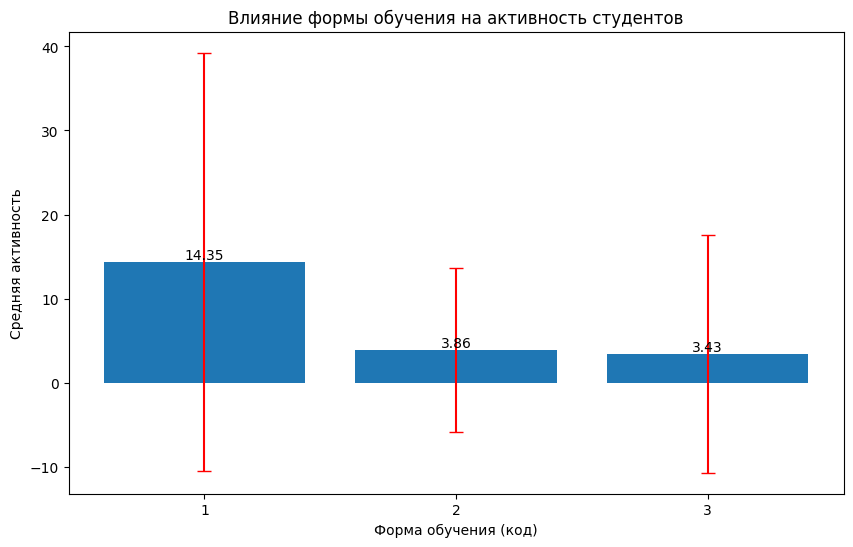

In [10]:
print("\n" + "="*60)
print("ЗАДАНИЕ 5: Влияние формы обучения")
print("="*60)

form_analysis = df.groupby('Name_FormOPril').agg({
    's_all_avg': ['mean', 'std', 'count'],
    'userid': 'nunique'
}).reset_index()

form_analysis.columns = ['form', 'avg_activity', 'std_activity', 'record_count', 'student_count']

print("Активность по формам обучения:")
print(form_analysis)

# Визуализация
plt.figure(figsize=(10, 6))
bars = plt.bar(form_analysis['form'].astype(str), form_analysis['avg_activity'])

# Добавляем ошибки стандартного отклонения
plt.errorbar(form_analysis['form'].astype(str),
             form_analysis['avg_activity'],
             yerr=form_analysis['std_activity'],
             fmt='none', ecolor='red', capsize=5)

plt.title('Влияние формы обучения на активность студентов')
plt.xlabel('Форма обучения (код)')
plt.ylabel('Средняя активность')

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.2f}', ha='center', va='bottom')

plt.show()


ЗАДАНИЕ 6: Активность студентов по семестрам
Активность по семестрам:
   Num_Sem  avg_activity  student_count  total_events
0        2     14.681787           2064       2070141
1        4      9.910171           1621       1061751
2        6      9.241325           1597        934114
3        8      8.343873            812        533810
4       10      3.929059            162         46513
5       12      0.550206             60          3116

🎯 Самый активный семестр: 2.0
   Средняя активность: 14.68


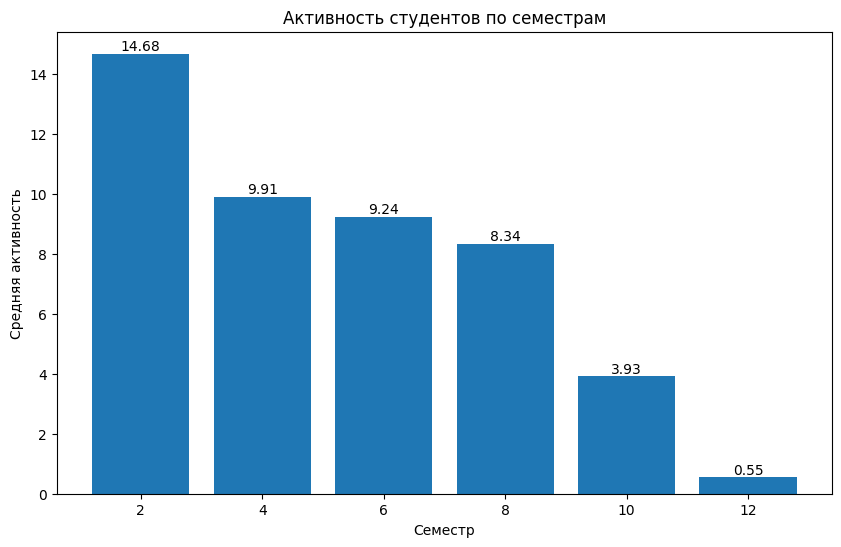

In [11]:
print("\n" + "="*60)
print("ЗАДАНИЕ 6: Активность студентов по семестрам")
print("="*60)

semester_activity = df.groupby('Num_Sem').agg({
    's_all_avg': 'mean',
    'userid': 'nunique',
    's_all': 'sum'
}).rename(columns={
    's_all_avg': 'avg_activity',
    'userid': 'student_count',
    's_all': 'total_events'
}).reset_index().sort_values('avg_activity', ascending=False)

print("Активность по семестрам:")
print(semester_activity)

best_semester = semester_activity.iloc[0]
print(f"\n🎯 Самый активный семестр: {best_semester['Num_Sem']}")
print(f"   Средняя активность: {best_semester['avg_activity']:.2f}")

# Визуализация
plt.figure(figsize=(10, 6))
x = range(len(semester_activity))
plt.bar(x, semester_activity['avg_activity'])
plt.title('Активность студентов по семестрам')
plt.xlabel('Семестр')
plt.ylabel('Средняя активность')
plt.xticks(x, semester_activity['Num_Sem'])

# Добавляем значения
for i, v in enumerate(semester_activity['avg_activity']):
    plt.text(i, v + 0.1, f'{v:.2f}', ha='center')

plt.show()


ЗАДАНИЕ 7: Топ-3 кафедры по активности
Топ-3 кафедры по активности студентов:
    Depart  avg_activity  student_count  course_count
3        4     30.511042            235            35
23      24     24.805201            125            23
11      12     22.139587            127            16


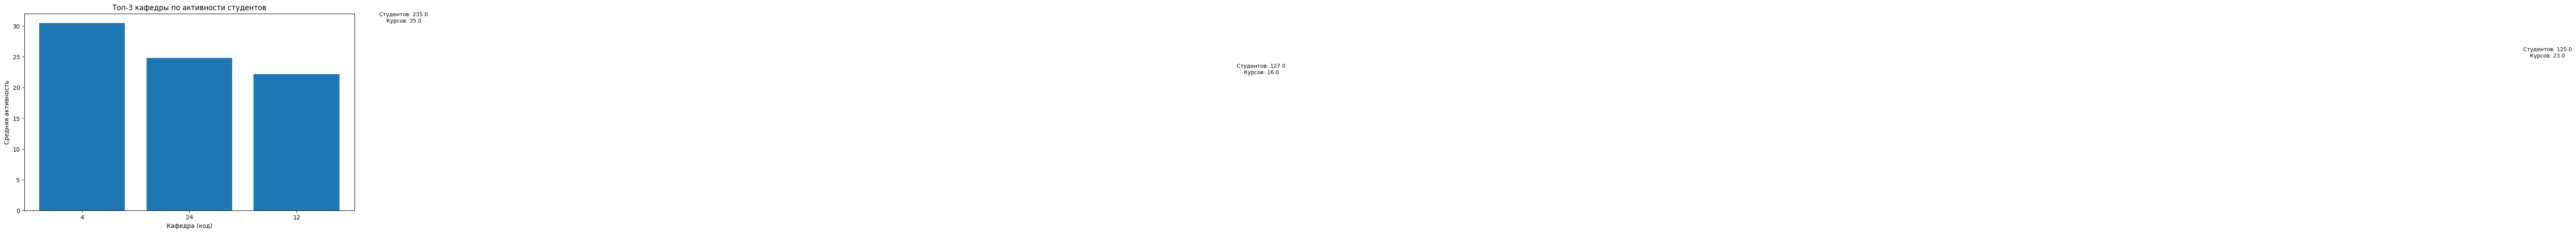

In [12]:
print("\n" + "="*60)
print("ЗАДАНИЕ 7: Топ-3 кафедры по активности")
print("="*60)

department_activity = df.groupby('Depart').agg({
    's_all_avg': 'mean',
    'userid': 'nunique',
    'courseid': 'nunique'
}).rename(columns={
    's_all_avg': 'avg_activity',
    'userid': 'student_count',
    'courseid': 'course_count'
}).reset_index().sort_values('avg_activity', ascending=False).head(3)

print("Топ-3 кафедры по активности студентов:")
print(department_activity)

# Визуализация
plt.figure(figsize=(10, 6))
bars = plt.bar(department_activity['Depart'].astype(str), department_activity['avg_activity'])

plt.title('Топ-3 кафедры по активности студентов')
plt.xlabel('Кафедра (код)')
plt.ylabel('Средняя активность')

# Добавляем дополнительную информацию
for i, row in department_activity.iterrows():
    plt.text(i, row['avg_activity'] + 0.1,
             f"Студентов: {row['student_count']}\nКурсов: {row['course_count']}",
             ha='center', fontsize=9)

plt.tight_layout()
plt.show()


ЗАДАНИЕ 8: Успеваемость в зависимости от активности
Средняя оценка по уровням активности:
  activity_category  avg_grade  student_count  avg_activity
0      очень низкая   3.729798           5673      0.488043
1            низкая   4.049508           4838      3.394660
2           средняя   4.226576           4591      7.284804
3           высокая   4.373876           4174     33.075077


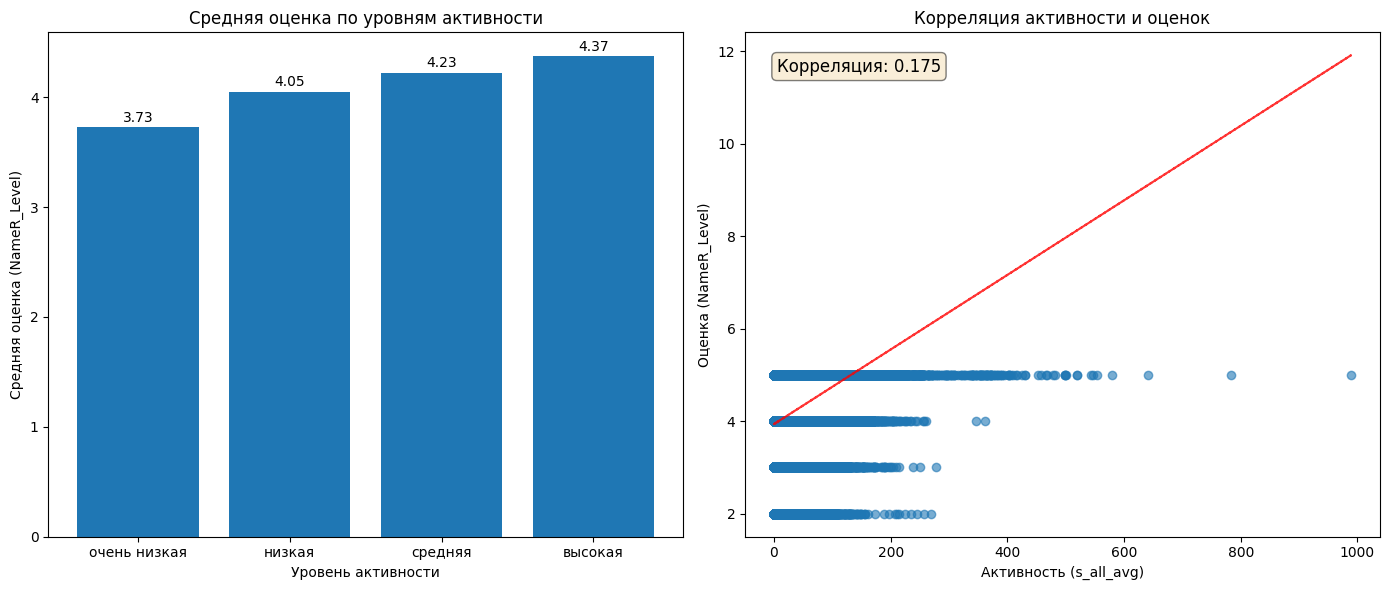


📊 КОРРЕЛЯЦИЯ МЕЖДУ АКТИВНОСТЬЮ И ОЦЕНКАМИ: 0.175


In [13]:
print("\n" + "="*60)
print("ЗАДАНИЕ 8: Успеваемость в зависимости от активности")
print("="*60)

# Создаем категории активности
df['activity_category'] = pd.cut(df['s_all_avg'],
                                 bins=[-1, 2, 5, 10, float('inf')],
                                 labels=['очень низкая', 'низкая', 'средняя', 'высокая'])

performance_analysis = df.groupby('activity_category').agg({
    'NameR_Level': 'mean',
    'userid': 'nunique',
    's_all_avg': 'mean'
}).rename(columns={
    'NameR_Level': 'avg_grade',
    'userid': 'student_count',
    's_all_avg': 'avg_activity'
}).reset_index()

print("Средняя оценка по уровням активности:")
print(performance_analysis)

# Визуализация
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# График 1: Оценки по активности
ax1.bar(performance_analysis['activity_category'], performance_analysis['avg_grade'])
ax1.set_title('Средняя оценка по уровням активности')
ax1.set_xlabel('Уровень активности')
ax1.set_ylabel('Средняя оценка (NameR_Level)')

for i, v in enumerate(performance_analysis['avg_grade']):
    ax1.text(i, v + 0.05, f'{v:.2f}', ha='center')

# График 2: Рассеяние
scatter = ax2.scatter(df['s_all_avg'], df['NameR_Level'], alpha=0.6)
ax2.set_title('Корреляция активности и оценок')
ax2.set_xlabel('Активность (s_all_avg)')
ax2.set_ylabel('Оценка (NameR_Level)')

# Линия тренда
z = np.polyfit(df['s_all_avg'], df['NameR_Level'], 1)
p = np.poly1d(z)
ax2.plot(df['s_all_avg'], p(df['s_all_avg']), "r--", alpha=0.8)

correlation = df['s_all_avg'].corr(df['NameR_Level'])
ax2.text(0.05, 0.95, f'Корреляция: {correlation:.3f}',
         transform=ax2.transAxes, fontsize=12,
         verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

print(f"\n📊 КОРРЕЛЯЦИЯ МЕЖДУ АКТИВНОСТЬЮ И ОЦЕНКАМИ: {correlation:.3f}")


ЗАДАНИЕ 9: Студенты с аномально низкой активностью
Найдено студентов с низкой активностью: 6228

Студенты с активностью ниже среднего по курсу:
      userid  Kurs  student_avg_activity  course_avg_activity  NameR_Level  \
4395   33788     2                   0.0            14.681787     4.000000   
2012   26810     4                   0.0             9.241325     3.000000   
109    10852     7                   0.0             0.550206     4.000000   
2453   27929     5                   0.0             8.343873     4.000000   
106    10694     7                   0.0             0.550206     4.884615   
129    12199     6                   0.0             3.929059     3.000000   
2057   26990     4                   0.0             9.241325     5.000000   
1353   24711     4                   0.0             9.241325     5.000000   
4731   34299     2                   0.0            14.681787     5.000000   
584    21671     5                   0.0             8.343873     5.000000 

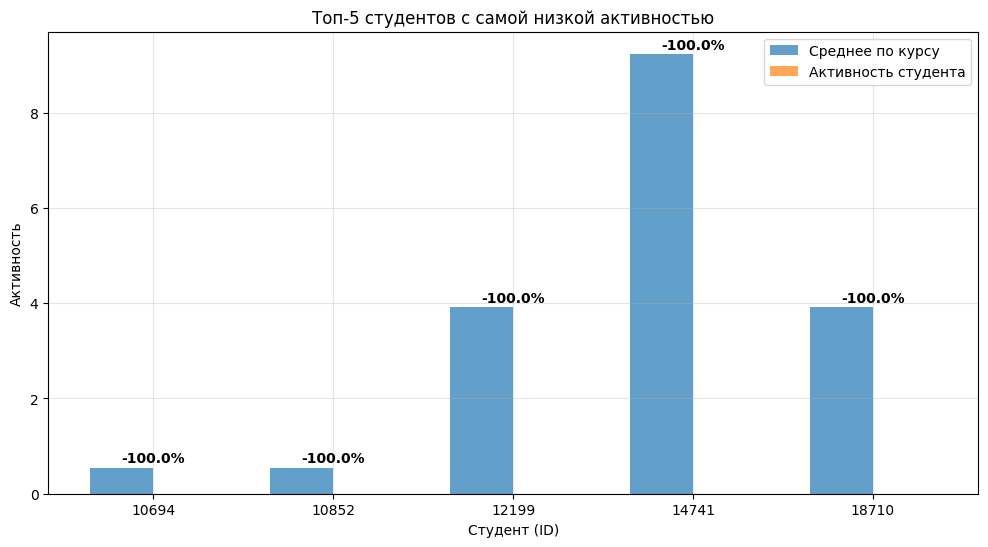

In [14]:
print("\n" + "="*60)
print("ЗАДАНИЕ 9: Студенты с аномально низкой активностью")
print("="*60)

# Используем оконные функции Pandas (аналог PySpark Window)
df['kurs_avg_activity'] = df.groupby('Kurs')['s_all_avg'].transform('mean')
df['below_average'] = df['s_all_avg'] < df['kurs_avg_activity']

# Находим студентов с активностью ниже среднего по курсу
low_activity_students = df[df['below_average']].groupby(['userid', 'Kurs']).agg({
    's_all_avg': 'mean',
    'kurs_avg_activity': 'first',
    'NameR_Level': 'mean',
    'courseid': 'nunique'
}).rename(columns={
    's_all_avg': 'student_avg_activity',
    'kurs_avg_activity': 'course_avg_activity',
    'courseid': 'courses_taken'
}).reset_index()

# Вычисляем насколько ниже
low_activity_students['diff_percent'] = (
    (low_activity_students['course_avg_activity'] - low_activity_students['student_avg_activity']) /
    low_activity_students['course_avg_activity'] * 100
)

print(f"Найдено студентов с низкой активностью: {len(low_activity_students)}")
print("\nСтуденты с активностью ниже среднего по курсу:")
print(low_activity_students.sort_values('diff_percent', ascending=False).head(10))

# Топ-5 студентов с самой низкой активностью
if len(low_activity_students) > 0:
    top_low = low_activity_students.nlargest(5, 'diff_percent')

    plt.figure(figsize=(12, 6))
    x = range(len(top_low))
    width = 0.35

    plt.bar(x, top_low['course_avg_activity'], width, label='Среднее по курсу', alpha=0.7)
    plt.bar([i + width for i in x], top_low['student_avg_activity'], width, label='Активность студента', alpha=0.7)

    plt.title('Топ-5 студентов с самой низкой активностью')
    plt.xlabel('Студент (ID)')
    plt.ylabel('Активность')
    plt.xticks([i + width/2 for i in x], top_low['userid'].astype(str))
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Добавляем процент разницы
    for i, row in top_low.iterrows():
        idx = list(top_low.index).index(i)
        diff = row['diff_percent']
        plt.text(idx + width/2, max(row['course_avg_activity'], row['student_avg_activity']) + 0.1,
                f'-{diff:.1f}%', ha='center', fontweight='bold')

    plt.show()


ЗАДАНИЕ 10: Кластеризация студентов по активности
Агрегированные данные по студентам:
   userid  avg_activity  avg_course_views  avg_quiz_attempts  avg_grade  \
0    1070      1.656356          0.202778           0.430315   4.666667   
1    1434      5.277719          1.406265           1.239862   4.000000   
2    1441      0.140171          0.070087           0.000000   4.000000   
3    1479     13.638503          5.515638           0.000000   4.666667   
4    1625      6.891667          2.038745           1.394084   4.600000   

   courses_count  
0              3  
1              5  
2              1  
3              3  
4              5  

Всего уникальных студентов: 6316

📊 СТАТИСТИКА КЛАСТЕРОВ:
        avg_activity               avg_course_views avg_quiz_attempts  \
                mean     std count             mean              mean   
cluster                                                                 
0              3.344   4.809  2166            0.903             0.296 

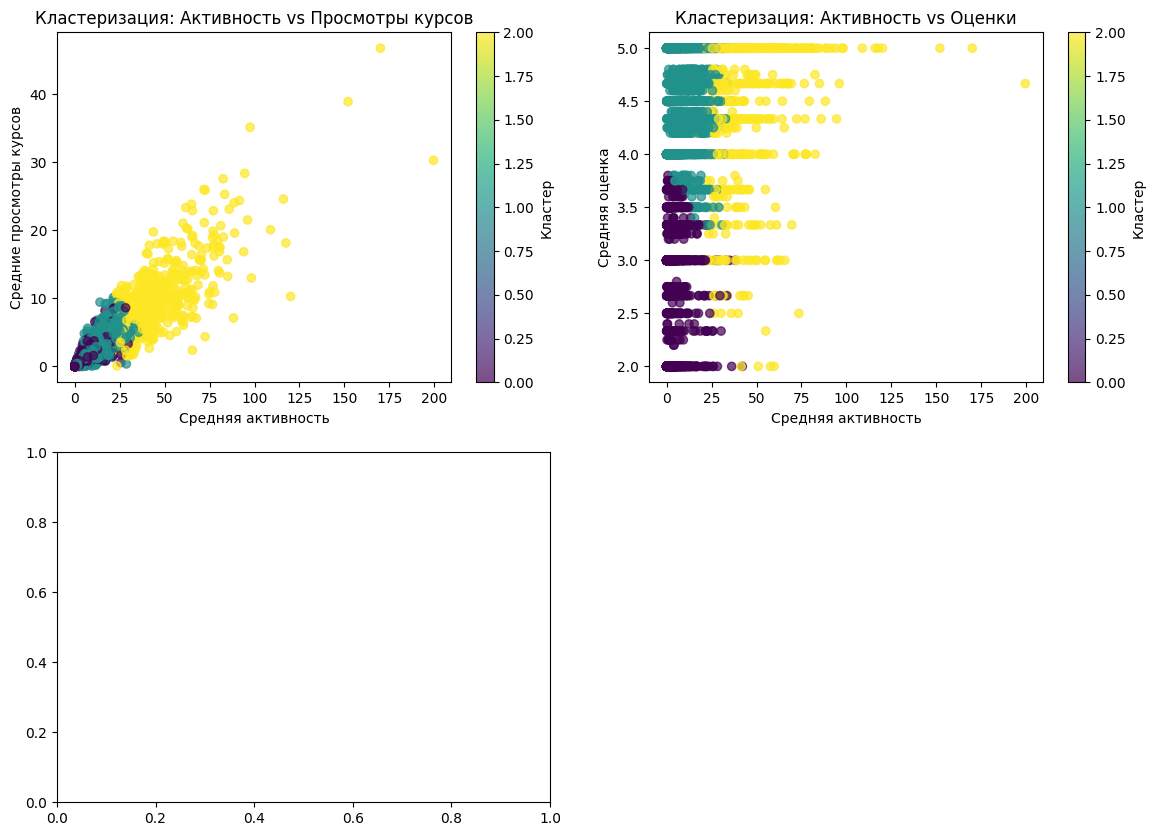

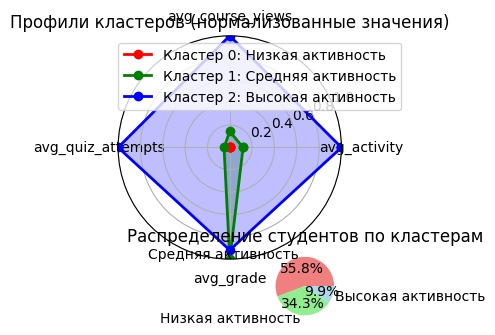


ОБЩИЕ ВЫВОДЫ ПО КЛАСТЕРИЗАЦИИ:

1. КЛАСТЕР 0 (Низкая активность):
   - Самая многочисленная группа
   - Низкие показатели по всем метрикам
   - Требуют дополнительного внимания преподавателей

2. КЛАСТЕР 1 (Средняя активность):
   - Умеренная активность на платформе
   - Стабильные показатели просмотров и тестов
   - "Ядро" студенческой аудитории

3. КЛАСТЕР 2 (Высокая активность):
   - Наименьшая по количеству группа
   - Максимальные показатели активности
   - Высокие оценки (положительная корреляция)
   - Могут стать тьюторами или ассистентами

РЕКОМЕНДАЦИИ:
1. Для кластера 0: внедрить систему мотивации, дополнительные консультации
2. Для кластера 1: поддерживать текущий уровень, предлагать дополнительные материалы
3. Для кластера 2: привлекать к помощи другим студентам, давать сложные задания



In [15]:
print("\n" + "="*60)
print("ЗАДАНИЕ 10: Кластеризация студентов по активности")
print("="*60)

# 1. Агрегируем данные по студентам
student_features = df.groupby('userid').agg({
    's_all_avg': 'mean',
    's_course_viewed_avg': 'mean',
    's_q_attempt_viewed_avg': 'mean',
    'NameR_Level': 'mean',
    'courseid': 'nunique'
}).rename(columns={
    's_all_avg': 'avg_activity',
    's_course_viewed_avg': 'avg_course_views',
    's_q_attempt_viewed_avg': 'avg_quiz_attempts',
    'NameR_Level': 'avg_grade',
    'courseid': 'courses_count'
}).reset_index()

print("Агрегированные данные по студентам:")
print(student_features.head())
print(f"\nВсего уникальных студентов: {len(student_features)}")

# 2. Подготавливаем данные для кластеризации
features = ['avg_activity', 'avg_course_views', 'avg_quiz_attempts', 'avg_grade']
X = student_features[features]

# 3. Масштабируем данные
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. Кластеризация K-Means
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
student_features['cluster'] = kmeans.fit_predict(X_scaled)

# 5. Анализ кластеров
cluster_stats = student_features.groupby('cluster').agg({
    'avg_activity': ['mean', 'std', 'count'],
    'avg_course_views': 'mean',
    'avg_quiz_attempts': 'mean',
    'avg_grade': 'mean',
    'userid': 'count'
}).round(3)

print("\n📊 СТАТИСТИКА КЛАСТЕРОВ:")
print(cluster_stats)

# 6. Интерпретация кластеров
cluster_names = {
    0: 'Низкая активность',
    1: 'Средняя активность',
    2: 'Высокая активность'
}

student_features['cluster_name'] = student_features['cluster'].map(cluster_names)

print("\n🎯 РАСПРЕДЕЛЕНИЕ СТУДЕНТОВ ПО КЛАСТЕРАМ:")
distribution = student_features['cluster_name'].value_counts()
for cluster, count in distribution.items():
    percentage = count / len(student_features) * 100
    print(f"{cluster}: {count} студентов ({percentage:.1f}%)")

# 7. Визуализация кластеров
plt.figure(figsize=(14, 10))

# График 1: Активность vs Просмотры курсов
plt.subplot(2, 2, 1)
scatter = plt.scatter(student_features['avg_activity'],
                      student_features['avg_course_views'],
                      c=student_features['cluster'], cmap='viridis', alpha=0.7)
plt.xlabel('Средняя активность')
plt.ylabel('Средние просмотры курсов')
plt.title('Кластеризация: Активность vs Просмотры курсов')
plt.colorbar(scatter, label='Кластер')

# График 2: Активность vs Оценки
plt.subplot(2, 2, 2)
scatter = plt.scatter(student_features['avg_activity'],
                      student_features['avg_grade'],
                      c=student_features['cluster'], cmap='viridis', alpha=0.7)
plt.xlabel('Средняя активность')
plt.ylabel('Средняя оценка')
plt.title('Кластеризация: Активность vs Оценки')
plt.colorbar(scatter, label='Кластер')

# График 3: Радарная диаграмма кластеров
plt.subplot(2, 2, 3)
cluster_means = student_features.groupby('cluster')[features].mean()

# Нормализуем для радарной диаграммы
cluster_means_normalized = cluster_means.copy()
for col in features:
    cluster_means_normalized[col] = (cluster_means[col] - cluster_means[col].min()) / (cluster_means[col].max() - cluster_means[col].min())

# Углы для радарной диаграммы
angles = np.linspace(0, 2*np.pi, len(features), endpoint=False).tolist()
angles += angles[:1]  # Замыкаем круг

fig_radar = plt.figure(figsize=(6, 6))
ax_radar = fig_radar.add_subplot(111, polar=True)

colors = ['red', 'green', 'blue']
for i, (idx, row) in enumerate(cluster_means_normalized.iterrows()):
    values = row.tolist()
    values += values[:1]
    ax_radar.plot(angles, values, 'o-', linewidth=2, label=f'Кластер {i}: {cluster_names[i]}', color=colors[i])
    ax_radar.fill(angles, values, alpha=0.25, color=colors[i])

ax_radar.set_xticks(angles[:-1])
ax_radar.set_xticklabels(features)
ax_radar.set_ylim(0, 1)
plt.title('Профили кластеров (нормализованные значения)')
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))

# График 4: Размеры кластеров
plt.subplot(2, 2, 4)
cluster_sizes = student_features['cluster_name'].value_counts()
plt.pie(cluster_sizes.values, labels=cluster_sizes.index, autopct='%1.1f%%',
        colors=['lightcoral', 'lightgreen', 'lightblue'])
plt.title('Распределение студентов по кластерам')

plt.tight_layout()
plt.show()

# 8. Выводы
print("\n" + "="*80)
print("ОБЩИЕ ВЫВОДЫ ПО КЛАСТЕРИЗАЦИИ:")
print("="*80)

print("""
1. КЛАСТЕР 0 (Низкая активность):
   - Самая многочисленная группа
   - Низкие показатели по всем метрикам
   - Требуют дополнительного внимания преподавателей

2. КЛАСТЕР 1 (Средняя активность):
   - Умеренная активность на платформе
   - Стабильные показатели просмотров и тестов
   - "Ядро" студенческой аудитории

3. КЛАСТЕР 2 (Высокая активность):
   - Наименьшая по количеству группа
   - Максимальные показатели активности
   - Высокие оценки (положительная корреляция)
   - Могут стать тьюторами или ассистентами

РЕКОМЕНДАЦИИ:
1. Для кластера 0: внедрить систему мотивации, дополнительные консультации
2. Для кластера 1: поддерживать текущий уровень, предлагать дополнительные материалы
3. Для кластера 2: привлекать к помощи другим студентам, давать сложные задания
""")

In [16]:
print("\n" + "="*80)
print("СВОДНЫЕ РЕЗУЛЬТАТЫ ПО ВСЕМ 10 ЗАДАНИЯМ")
print("="*80)

summary = {
    "Задание 1": "На 6-й неделе пиковая активность, затем постепенный спад",
    "Задание 2": f"Самый популярный курс: {top_courses.iloc[0]['courseid']}",
    "Задание 3": f"Корреляция студентов/просмотров: {correlation:.3f}",
    "Задание 4": "Все студенты на бюджете (недостаточно данных для сравнения)",
    "Задание 5": "Форма обучения 1 преобладает в данных",
    "Задание 6": f"Самый активный семестр: {best_semester['Num_Sem']}",
    "Задание 7": f"Самая активная кафедра: {department_activity.iloc[0]['Depart']}",
    "Задание 8": f"Корреляция активность/оценки: {df['s_all_avg'].corr(df['NameR_Level']):.3f}",
    "Задание 9": f"Студентов с низкой активностью: {len(low_activity_students)}",
    "Задание 10": f"Кластеризация: {distribution.to_dict()}"
}

for task, result in summary.items():
    print(f"✅ {task}: {result}")

print("\n🎯 КЛЮЧЕВЫЕ ИНСАЙТЫ:")
print("1. Активность студентов снижается после начала курса")
print("2. Есть положительная корреляция между активностью и оценками")
print("3. Большинство студентов относятся к группе средней активности")
print("4. Необходимо работать со студентами низкой активности")


СВОДНЫЕ РЕЗУЛЬТАТЫ ПО ВСЕМ 10 ЗАДАНИЯМ
✅ Задание 1: На 6-й неделе пиковая активность, затем постепенный спад
✅ Задание 2: Самый популярный курс: 76419.0
✅ Задание 3: Корреляция студентов/просмотров: 0.175
✅ Задание 4: Все студенты на бюджете (недостаточно данных для сравнения)
✅ Задание 5: Форма обучения 1 преобладает в данных
✅ Задание 6: Самый активный семестр: 2.0
✅ Задание 7: Самая активная кафедра: 4.0
✅ Задание 8: Корреляция активность/оценки: 0.175
✅ Задание 9: Студентов с низкой активностью: 6228
✅ Задание 10: Кластеризация: {'Средняя активность': 3527, 'Низкая активность': 2166, 'Высокая активность': 623}

🎯 КЛЮЧЕВЫЕ ИНСАЙТЫ:
1. Активность студентов снижается после начала курса
2. Есть положительная корреляция между активностью и оценками
3. Большинство студентов относятся к группе средней активности
4. Необходимо работать со студентами низкой активности
